# Lazy `NetCDF` — complete cookbook

NetCDFs are typically the heaviest single files in a GIS pipeline. Pyramids exposes four lazy entry points that together cover single-file reads, multi-file stacks, zero-copy Zarr indexing, and xarray interop. This notebook walks through them against local test data.

## What you'll see

1. `NetCDF.read_array(variable, chunks=…)` — eager vs lazy returns.
2. CF `unpack=True` — applying `scale_factor` / `add_offset` lazily.
3. `NetCDF.open_mfdataset(paths, variable)` — stack many files along a leading time axis.
4. `NetCDF.to_kerchunk` / `combine_kerchunk` — zero-copy cube indexing (requires `[lazy]`).
5. Handing a pyramids lazy array to `xarray.DataArray` — pyramids stays a peer, not a backend.

## Requirements

```bash
pip install 'pyramids-gis[lazy]'   # core lazy path + kerchunk (h5py)
pip install xarray                 # + xarray interop (a peer dep, not a pyramids extra)
```

## Setup

In [1]:
%matplotlib inline

from pathlib import Path

DATA = (Path('..') / '..' / '..' / 'examples' / 'data').resolve() / 'netcdf'
sorted(p.name for p in DATA.glob('*.nc'))

['cf__4v__1d3-3d1__proj__y-desc.nc',
 'coards__4v__1d2-2d2__scaleoffset__y-asc.nc']

## 1. `NetCDF.read_array(variable, chunks=…)`

`chunks=None` (the default) returns a `numpy.ndarray`. Any other value flips to a `dask.array.Array` whose chunks are materialised on demand through GDAL's MDArray reader.

In [2]:
from pyramids.netcdf import NetCDF

nc = NetCDF.read_file(DATA / 'cf__4v__1d3-3d1__proj__y-desc.nc')
nc.variable_names

['values']

### Visualise the test variable

`nc` is a concrete, file-backed `NetCDF`, so we can plot the `values` variable before exploring the lazy reads.
`plot` materialises the first time slice and renders it as a map.

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/matplotlib/colors.py:824: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


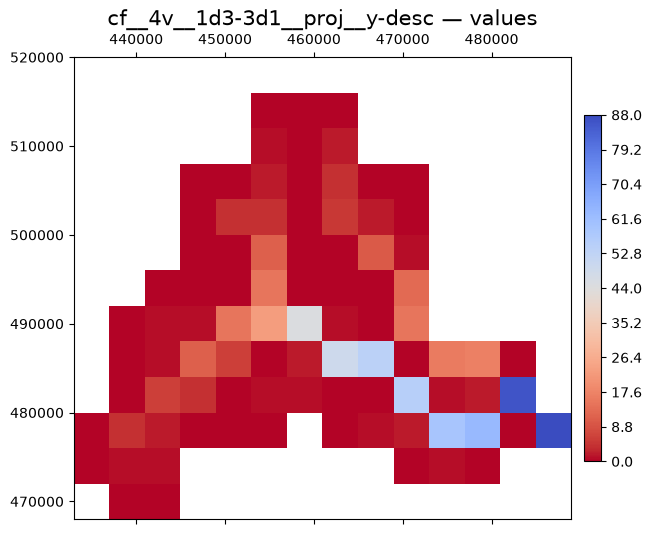

In [3]:
nc.plot(variable='values', title='cf__4v__1d3-3d1__proj__y-desc — values')

In [4]:
# Eager — numpy.
eager = nc.read_array('values')
type(eager).__name__, eager.shape, eager.dtype

('ndarray', (3, 13, 14), dtype('float32'))

In [5]:
# Lazy — dask array. One chunk per time step.
lazy = nc.read_array('values', chunks=(1, -1, -1))
type(lazy).__name__, lazy.shape, lazy.chunks

('Array', (3, 13, 14), ((1, 1, 1), (13,), (14,)))

In [6]:
# Reduce along time — no I/O until .compute().
per_cell_mean = lazy.mean(axis=0)
len(per_cell_mean.__dask_graph__())

7

In [7]:
materialised = per_cell_mean.compute()
materialised.shape, float(materialised.min()), float(materialised.max())

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


((13, 14), -inf, 88.0)

## 2. CF `unpack=True` — lazy scale/offset

NetCDF variables often store packed ints with `scale_factor` / `add_offset` CF attributes. `unpack=True` applies the transformation in the dask graph — no materialisation.

In [8]:
nc_packed = NetCDF.read_file(DATA / 'coards__4v__1d2-2d2__scaleoffset__y-asc.nc')
nc_packed.variable_names

['z', 'q']

In [9]:
# Variable with scale_factor / add_offset set.
packed_lazy = nc_packed.read_array(
    nc_packed.variable_names[0],
    unpack=True,
    chunks='auto',
)
packed_lazy.dtype

dtype('float64')

## 3. `open_mfdataset(paths, variable)` — multi-file stack

Unlike `xarray.open_mfdataset`, the pyramids helper is deliberately narrow: one variable at a time, no combine strategies. `parallel=True` fans out per-file opens via `dask.delayed`.

In [10]:
# Re-use the same file three times for a 3-element stack.
paths = [DATA / 'cf__4v__1d3-3d1__proj__y-desc.nc'] * 3
stack = NetCDF.open_mfdataset(paths, variable='values')
stack.shape

(3, 3, 13, 14)

In [11]:
# Per-file mean — reduces back to one (T, H, W) slab.
stack_mean = stack.mean(axis=0).compute()
stack_mean.shape

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


(3, 13, 14)

## 4. Kerchunk — zero-copy cube indexing

A kerchunk manifest is a JSON document containing byte-range pointers into each source file; no pixel data is moved. Requires the `[lazy]` extra. The helper raises a clean `ImportError` if kerchunk is missing.

In [12]:
import tempfile

workdir = Path(tempfile.mkdtemp(prefix='pyramids-kerchunk-'))
manifest_path = workdir / 'single.json'

try:
    manifest = nc.to_kerchunk(manifest_path)
    outcome = f'manifest has {len(manifest.get("refs", manifest))} entries'
except ImportError as exc:
    outcome = f'extra missing: {exc}'
outcome

'manifest has 16 entries'

In [13]:
# Combine many files into one manifest. The test file's leading
# axis is named 'bands'; real-world cubes use 'time'.
combined_path = workdir / 'combined.json'
try:
    manifest = NetCDF.combine_kerchunk(
        paths,
        combined_path,
        concat_dims=('bands',),
        identical_dims=(),
    )
    outcome = manifest_path.exists(), combined_path.exists()
except ImportError as exc:
    outcome = f'extra missing: {exc}'
outcome

(True, True)

## 5. Handing a pyramids lazy array to xarray

Pyramids is a peer of xarray, not a backend beneath it — the lazy read goes through pyramids' `CachingFileManager` + GDAL MDArray, no xarray engine plugin in the middle. If you need `xarray.DataArray` ergonomics downstream, `pip install xarray` (a peer dep, not a pyramids extra) and wrap the lazy array yourself:

In [14]:
try:
    import xarray as xr

    lazy = nc.read_array('values', chunks=(1, -1, -1))
    da = xr.DataArray(lazy, dims=('band', 'y', 'x'), name='values')
    outcome = da.name, tuple(da.dims), da.shape
except ImportError as exc:
    outcome = f'extra missing: {exc}'
outcome

('values', ('band', 'y', 'x'), (3, 13, 14))

## Closing notes

- `read_array` and `open_mfdataset` only need the `[lazy]` extra.
- `to_kerchunk` and `combine_kerchunk` also ship in `[lazy]` — they raise a clean `ImportError` naming the extra on minimal installs.
- `NetCDF.to_xarray()` / `.from_xarray()` need `xarray` (`pip install xarray`, a peer dep — not a pyramids extra); pyramids does not install xarray by default.
- For a real ERA5-on-AWS walkthrough, see `dask-lazy-netcdf.ipynb`.